# Métodos y Modelos Cuantitativos
## Sesión 1 — Programación Lineal con Python

En este Notebook se implementará un modelo de Programación Lineal utilizando Python.

Se utilizará el caso **EcoMuebles**, analizado previamente en clase, para:

1. Representar matemáticamente un problema de optimización.
2. Resolver el modelo mediante Python.
3. Visualizar gráficamente la región factible.
4. Interpretar la solución óptima.
5. Analizar el uso de los recursos y las holguras.
6. Evaluar diferentes escenarios de capacidad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# Caso de estudio: EcoMuebles

EcoMuebles produce diariamente dos tipos de productos:

- Mesas rústicas.
- Sillas estándar.

Cada producto consume madera y horas de mano de obra.

| Recurso | Mesa | Silla | Disponibilidad |
|---|---:|---:|---:|
| Madera | 4 | 2 | 100 |
| Mano de obra | 3 | 1 | 60 |
| Ganancia | $80 | $30 | |

Se desea determinar cuántas mesas y sillas deben producirse diariamente para maximizar la ganancia.

## Formulación matemática

### Variables de decisión

$x_1$ = número de mesas a producir.

$x_2$ = número de sillas a producir.

### Función objetivo

$$
Max\ Z = 80x_1 + 30x_2
$$

### Restricciones

Madera disponible:

$$
4x_1 + 2x_2 \leq 100
$$

Mano de obra disponible:

$$
3x_1 + x_2 \leq 60
$$

No negatividad:

$$
x_1,x_2 \geq 0
$$

## Representación del modelo en Python

SciPy utiliza la función `linprog()` para resolver problemas de Programación Lineal.

El modelo debe representarse mediante vectores y matrices:

- `c`: coeficientes de la función objetivo.
- `A_ub`: coeficientes de las restricciones.
- `b_ub`: disponibilidad máxima de los recursos.
- `bounds`: límites de las variables.

Como `linprog()` trabaja por defecto con problemas de minimización, para maximizar una función objetivo multiplicaremos sus coeficientes por -1.

In [2]:
# Función objetivo
# Max Z = 80x1 + 30x2

c = [-80, -30]

# Restricciones
# 4x1 + 2x2 <= 100
# 3x1 + 1x2 <= 60

A = [
    [4, 2],
    [3, 1]
]

b = [
    100,
    60
]

# x1 >= 0
# x2 >= 0

limites = [
    (0, None),
    (0, None)
]

## Resolver el modelo

In [3]:
resultado = linprog(
    c,
    A_ub=A,
    b_ub=b,
    bounds=limites,
    method="highs"
)

print(resultado)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -1700.0
              x: [ 1.000e+01  3.000e+01]
            nit: 2
          lower:  residual: [ 1.000e+01  3.000e+01]
                 marginals: [ 0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf]
                 marginals: [ 0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00]
                 marginals: [-5.000e+00 -2.000e+01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0


## Extraer la solución

In [4]:
mesas = resultado.x[0]
sillas = resultado.x[1]
ganancia = -resultado.fun

print(f"Mesas a producir: {mesas:.0f}")
print(f"Sillas a producir: {sillas:.0f}")
print(f"Ganancia máxima: ${ganancia:,.2f}")

Mesas a producir: 10
Sillas a producir: 30
Ganancia máxima: $1,700.00


## Visualización gráfica

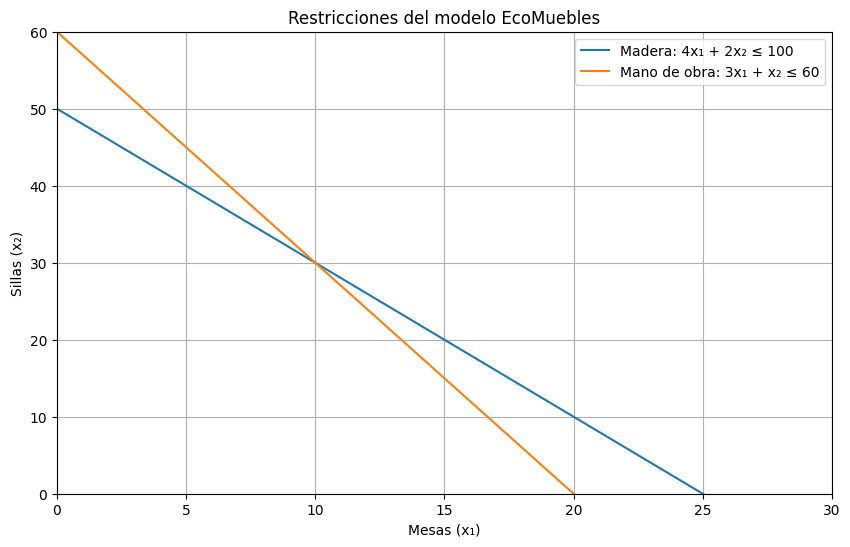

In [5]:
x1 = np.linspace(0, 30, 300)

# Restricción de madera:
# 4x1 + 2x2 <= 100

x2_madera = (100 - 4*x1) / 2

# Restricción de mano de obra:
# 3x1 + x2 <= 60

x2_trabajo = 60 - 3*x1

plt.figure(figsize=(10, 6))

plt.plot(x1, x2_madera, label="Madera: 4x₁ + 2x₂ ≤ 100")
plt.plot(x1, x2_trabajo, label="Mano de obra: 3x₁ + x₂ ≤ 60")

plt.xlim(0, 30)
plt.ylim(0, 60)

plt.xlabel("Mesas (x₁)")
plt.ylabel("Sillas (x₂)")
plt.title("Restricciones del modelo EcoMuebles")

plt.grid()
plt.legend()

plt.show()

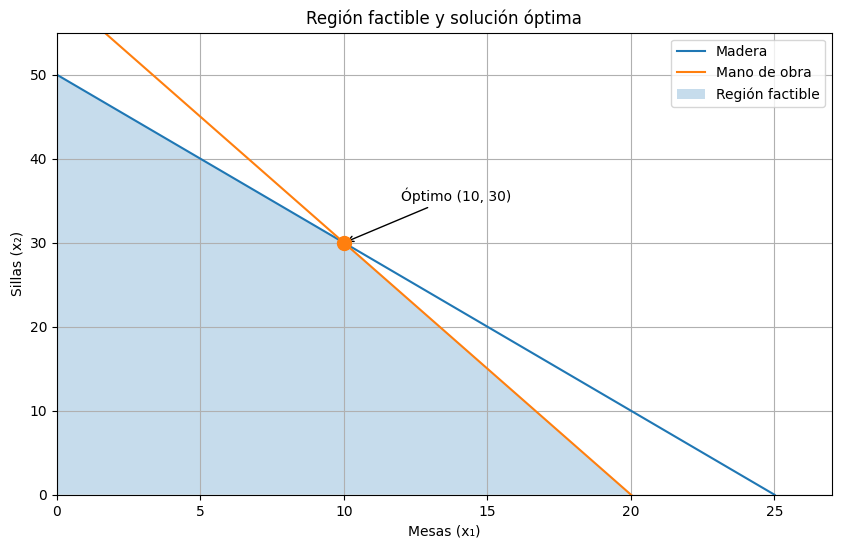

In [6]:
x1 = np.linspace(0, 25, 300)

x2_madera = (100 - 4*x1) / 2
x2_trabajo = 60 - 3*x1

x2_factible = np.minimum(x2_madera, x2_trabajo)
x2_factible = np.maximum(x2_factible, 0)

plt.figure(figsize=(10, 6))

plt.plot(x1, x2_madera, label="Madera")
plt.plot(x1, x2_trabajo, label="Mano de obra")

plt.fill_between(
    x1,
    0,
    x2_factible,
    where=(x2_factible >= 0),
    alpha=0.25,
    label="Región factible"
)

plt.scatter(mesas, sillas, s=100, zorder=5)

plt.annotate(
    f"Óptimo ({mesas:.0f}, {sillas:.0f})",
    (mesas, sillas),
    xytext=(mesas + 2, sillas + 5),
    arrowprops={"arrowstyle": "->"}
)

plt.xlim(0, 27)
plt.ylim(0, 55)

plt.xlabel("Mesas (x₁)")
plt.ylabel("Sillas (x₂)")
plt.title("Región factible y solución óptima")

plt.grid()
plt.legend()

plt.show()

## Interpretación de los resultados

### Recursos utilizados


In [7]:
madera_utilizada = 4*mesas + 2*sillas
trabajo_utilizado = 3*mesas + sillas

print(f"Madera utilizada: {madera_utilizada:.0f} de 100")
print(f"Mano de obra utilizada: {trabajo_utilizado:.0f} de 60")

Madera utilizada: 100 de 100
Mano de obra utilizada: 60 de 60


### Calcular holguras

In [8]:
holgura_madera = 100 - madera_utilizada
holgura_trabajo = 60 - trabajo_utilizado

print(f"Holgura de madera: {holgura_madera:.0f}")
print(f"Holgura de mano de obra: {holgura_trabajo:.0f}")

Holgura de madera: 0
Holgura de mano de obra: 0


In [9]:
recursos = pd.DataFrame({
    "Recurso": ["Madera", "Mano de obra"],
    "Disponible": [100, 60],
    "Utilizado": [madera_utilizada, trabajo_utilizado],
    "Holgura": [holgura_madera, holgura_trabajo]
})

recursos

,Recurso,Disponible,Utilizado,Holgura
0,Madera,100,100.0,0.0
1,Mano de obra,60,60.0,0.0


## Automatizando

In [11]:
def resolver_ecomuebles(madera=100, trabajo=60, ganancia_mesa=80, ganancia_silla=30):
    
    c = [-ganancia_mesa, -ganancia_silla]
    
    A = [
        [4, 2],
        [3, 1]
    ]
    
    b = [
        madera,
        trabajo
    ]
    
    resultado = linprog(
        c,
        A_ub=A,
        b_ub=b,
        bounds=[(0, None), (0, None)],
        method="highs"
    )
    
    return {
        "Mesas": float(resultado.x[0]),
        "Sillas": float(resultado.x[1]),
        "Ganancia": float(-resultado.fun)
    }

In [12]:
resolver_ecomuebles()

{'Mesas': 10.0, 'Sillas': 30.0, 'Ganancia': 1700.0}

In [13]:
resolver_ecomuebles(madera=120)

{'Mesas': -0.0, 'Sillas': 60.0, 'Ganancia': 1800.0}

In [14]:
resolver_ecomuebles(trabajo=70)

{'Mesas': 20.0, 'Sillas': 10.0, 'Ganancia': 1900.0}

In [15]:
resolver_ecomuebles(madera=120, trabajo=70)

{'Mesas': 10.0, 'Sillas': 40.0, 'Ganancia': 2000.0}

## Comparación de escenarios

In [16]:
escenarios = [
    ("Base", 100, 60),
    ("Más madera", 120, 60),
    ("Más trabajo", 100, 70),
    ("Más madera y trabajo", 120, 70)
]

resultados = []

for nombre, madera, trabajo in escenarios:
    
    solucion = resolver_ecomuebles(
        madera=madera,
        trabajo=trabajo
    )
    
    resultados.append({
        "Escenario": nombre,
        "Madera": madera,
        "Trabajo": trabajo,
        "Mesas": solucion["Mesas"],
        "Sillas": solucion["Sillas"],
        "Ganancia": solucion["Ganancia"]
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,Escenario,Madera,Trabajo,Mesas,Sillas,Ganancia
0,Base,100,60,10.0,30.0,1700.0
1,Más madera,120,60,-0.0,60.0,1800.0
2,Más trabajo,100,70,20.0,10.0,1900.0
3,Más madera y trabajo,120,70,10.0,40.0,2000.0


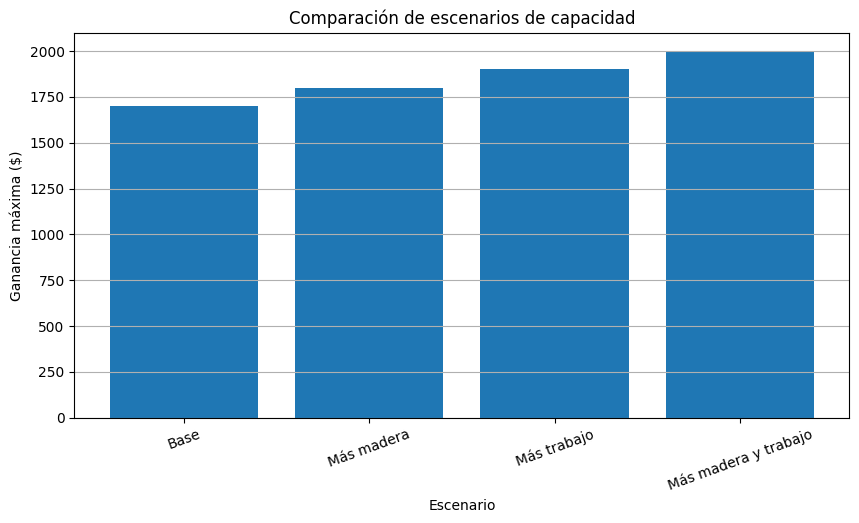

In [17]:
plt.figure(figsize=(10, 5))

plt.bar(
    df_resultados["Escenario"],
    df_resultados["Ganancia"]
)

plt.ylabel("Ganancia máxima ($)")
plt.xlabel("Escenario")
plt.title("Comparación de escenarios de capacidad")

plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

## Análisis de sensibilidad sencillo

In [ ]:
niveles_madera = range(60, 161, 5)

sensibilidad = []

for madera in niveles_madera:
    
    solucion = resolver_ecomuebles(
        madera=madera,
        trabajo=60
    )
    
    sensibilidad.append({
        "Madera": madera,
        "Ganancia": solucion["Ganancia"],
        "Mesas": solucion["Mesas"],
        "Sillas": solucion["Sillas"]
    })

df_sensibilidad = pd.DataFrame(sensibilidad)

df_sensibilidad

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_sensibilidad["Madera"],
    df_sensibilidad["Ganancia"],
    marker="o"
)

plt.xlabel("Madera disponible")
plt.ylabel("Ganancia máxima ($)")
plt.title("Efecto de la disponibilidad de madera sobre la ganancia")

plt.grid()

plt.show()

In [18]:
# Guardar resultados en un archivo CSV
df_resultados.to_csv('resultados_comparacion_escenarios.csv', index=False)

# Guardar la gráfica como JPG
plt.figure(figsize=(10, 5))
plt.bar(
    df_resultados["Escenario"],
    df_resultados["Ganancia"]
)
plt.ylabel("Ganancia máxima ($)")
plt.xlabel("Escenario")
plt.title("Comparación de escenarios de capacidad")
plt.xticks(rotation=20)
plt.grid(axis="y")

# Guardar la figura
plt.savefig('grafica_comparacion_escenarios.jpg', format='jpg')
plt.close()  # Cerrar la figura para liberar memoria


# Ejercicio

Una empresa de transporte debe decidir cuántos embarques de dos tipos de mercancía transportar diariamente.

| Característica | Mercancía A | Mercancía B |
|---|---:|---:|
| Peso por embarque | 4 ton | 2 ton |
| Volumen utilizado | 3 m³ | 4 m³ |
| Beneficio | $700 | $500 |

La empresa dispone diariamente de:

- 40 toneladas de capacidad de carga.
- 48 m³ de capacidad de volumen.

## Actividades

1. Definir las variables de decisión.
2. Formular la función objetivo.
3. Formular las restricciones.
4. Resolver el problema utilizando `linprog()`.
5. Determinar cuántos embarques de cada tipo deben transportarse.
6. Calcular el beneficio máximo.
7. Calcular las holguras de peso y volumen.
8. Representar gráficamente la región factible.
9. Interpretar los resultados desde el punto de vista de la empresa.

In [ ]:
# -------------------------------------------------------
# EJERCICIO DEL ALUMNO
# -------------------------------------------------------

# 1. Definir función objetivo


# 2. Definir restricciones


# 3. Definir límites de las variables


# 4. Ejecutar linprog()


# 5. Mostrar resultados


# 6. Calcular holguras


# 7. Graficar la región factible